# Similarity and Topic Diversity - EDA

## 0. Setup

In [1]:
#!pip install plotly

import warnings; warnings.filterwarnings('ignore')
import requests, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
from scipy import stats


sns.set_theme(style='whitegrid', context='notebook', font_scale=1.1)

# Palette 
BLUE = '#2b6cb0'
GREEN = '#276749'
RED = '#c53030'
DISC_COLOR = '#e53e3e'
DISC_YEAR  = 2018

# Paths
FEATURE_CSV = 'home/MoviesLSE/topic_diversity_index.csv'
OUTPUT_PATH = 'home/MoviesLSE/'
OMDB_PATH = '/home/MoviesLSE/topic_diversity_imdb_eda.csv'
BASICS_CSV = 'gs://moviesbucket-cam/title.basics.tsv.gz'
RATINGS_CSV = 'gs://moviesbucket-cam/title.ratings.tsv.gz'
GCS_OPTS = {'token': 'google_default'}
OMDB_API = 'YOUR_OMDB_API_KEY'
IMDB_CHUNKSIZE = 250_000

# ── Thresholds ───────────────────────────────────────────────
MIN_GENRE_FILMS = 100
MIN_YEAR_FILMS  = 3

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

## 1.a Download IMDB dataset

In [2]:
import subprocess
#subprocess.run(['wget', '-O', '/home/MoviesLSE/title.basics.tsv.gz', 
#                'https://datasets.imdbws.com/title.basics.tsv.gz'], check=True)
#!gcloud storage cp /home/MoviesLSE/title.basics.tsv.gz gs://moviesbucket-cam/
#subprocess.run(['wget', '-O', '/home/MoviesLSE/title.ratings.tsv.gz', 
#                'https://datasets.imdbws.com/title.ratings.tsv.gz'], check=True)
#!gcloud storage cp /home/MoviesLSE/title.ratings.tsv.gz gs://moviesbucket-cam/
## 1. Load Features
feature_cols = ['imdb_id', 'title', 'n_sentences', 'mean_cosine_similarity', 'TDI', 'dominant_topic']

if 'film_df' in globals() and set(feature_cols).issubset(film_df.columns):
    features = film_df[feature_cols].copy()
elif 'result' in globals() and set(feature_cols).issubset(result.columns):
    features = result[feature_cols].copy()
else:
    features = pd.read_csv(FEATURE_CSV, usecols=feature_cols)

features = features.dropna(subset=['imdb_id'])
print(f'Features: {len(features):,} films')

Features: 746 films


## 1.b Load IMDb dataset

In [3]:
def read_imdb_filtered(path, usecols, chunksize=IMDB_CHUNKSIZE):
    """Read a large IMDb TSV/TSV.GZ from GCS in chunks and keep only wanted tconst rows."""
    chunks = []
    reader = pd.read_csv(
        path,
        sep='\t',
        usecols=usecols,
        dtype='string',
        na_values='\\N',
        keep_default_na=True,
        storage_options=GCS_OPTS,
        chunksize=chunksize,
        compression='infer',
    )

    for chunk in reader:
        if not chunk.empty:
            chunks.append(chunk)

    if not chunks:
        return pd.DataFrame(columns=usecols)
    return pd.concat(chunks, ignore_index=True)


basics = read_imdb_filtered(
    BASICS_CSV,
    ['tconst', 'primaryTitle', 'titleType', 'startYear', 'runtimeMinutes', 'genres'],
)

basics = basics[basics['titleType'].eq('movie')].copy()

ratings = read_imdb_filtered(
    RATINGS_CSV,
    ['tconst', 'averageRating', 'numVotes'],
)


meta = basics.merge(
    ratings[['tconst', 'averageRating', 'numVotes']],
    on='tconst',
    how='left',
)

meta['imdb_id'] = pd.to_numeric(
    meta['tconst'].str.replace(r'^tt0*', '', regex=True),
    errors='coerce',
).astype('Int64')

In [4]:
print(f'Matched feature ids: {features["imdb_id"].isin(meta["imdb_id"]).sum():,} / {len(features):,}')

Matched feature ids: 736 / 746


## 1.c Join & Clean Film Metrics and IMDB data

In [5]:
df_raw = features.merge(meta, on='imdb_id', how='left')

for col in ['runtimeMinutes', 'averageRating', 'TDI', 'mean_cosine_similarity', 'numVotes']:
    df_raw[col] = df_raw[col].astype(float)
for col in ['startYear', 'dominant_topic']:
    df_raw[col] = pd.to_numeric(df_raw[col])

df_raw.dropna(subset=['startYear'],inplace=True)  

df_raw['log_votes']       = np.log10(df_raw['numVotes'].clip(lower=1))
df_raw['era']             = np.where(df_raw['startYear'] >= DISC_YEAR, 'Post-2018', 'Pre-2018')

## 1.d Fetch Age Certification and Box Office value
To call this API you can obtein a key using this [link](http://www.omdbapi.com/)

In [6]:
FIELDS = ['Rated', 'BoxOffice']

def get_omdb_fields(imdb_id_tt, fields, api_key=OMDB_API):
    try:
        data = requests.get(
            f"http://www.omdbapi.com/?i={imdb_id_tt}&apikey={api_key}"
        ).json()
        return pd.Series({field: data.get(field, None) for field in fields})
    except Exception:
        return pd.Series({field: None for field in fields})

def load_or_fetch_omdb(df, tconst_col='tconst', fields=FIELDS,
                        cache_path=OMDB_PATH, api_key=OMDB_API):

    if os.path.exists(cache_path):
        print(f'Cache found at {cache_path} — loading ...')
        cache = pd.read_csv(cache_path, usecols = ['tconst', 'age_cert', 'box_office'])
        return df.merge(cache[[tconst_col] + ['age_cert', 'box_office']], on=tconst_col, how='left')

    else:
        print('No cache found — fetching all films from OMDB ...')
        omdb_data = df[tconst_col].apply(
            lambda x: (time.sleep(0.1) or get_omdb_fields(x, fields, api_key))
        )
        omdb_data.insert(0, tconst_col, df[tconst_col].values)
        cache = omdb_data

    return df.merge(cache[[tconst_col] + fields], on=tconst_col, how='left')

# ── Run ───────────────────────────────────────────────────────────
df = load_or_fetch_omdb(df_raw)

# Clean box_office
if 'BoxOffice' in df.columns:
    df['box_office'] = pd.to_numeric(
        df['BoxOffice'].str.replace(r'[$,]', '', regex=True),
        errors='coerce'
    )

Cache found at /home/MoviesLSE/topic_diversity_imdb_eda.csv — loading ...


## 4. Metric Distributions - Top 10 Movies by Metric

In [7]:
cols = ['title', 'startYear', 'age_cert', 'averageRating', 'numVotes', 
        'TDI', 'mean_cosine_similarity', 'box_office']
result = df[['imdb_id', ] + cols].copy()

     
print('Most TOPIC REPETITIVE films (lowest TDI = sentences cluster in few topics)')
display(result.sort_values('TDI', ascending=True).head(10)[cols].reset_index(drop=True))

print('Most TOPIC DIVERSE films (highest TDI = sentences spread across many topics)')
display(result.sort_values('TDI', ascending=False).head(10)[cols].reset_index(drop=True))

Most TOPIC REPETITIVE films (lowest TDI = sentences cluster in few topics)


,title,startYear,age_cert,averageRating,numVotes,TDI,mean_cosine_similarity,box_office
0,The Great Wall,2016,PG-13,5.9000,159225.0000,0.8277,0.7850,45540830.0000
1,Greyhound,2020,PG-13,7.0000,133031.0000,0.8429,0.7368,NaN
2,Sisu,2022,R,6.9000,121193.0000,0.8734,0.8557,7265622.0000
3,Angels & Demons,2009,PG-13,6.7000,325720.0000,0.8834,0.7930,133375846.0000
4,300,2006,R,7.6000,911651.0000,0.8881,0.8176,210629101.0000
5,Alpha,2018,PG-13,6.6000,71752.0000,0.8889,0.8636,35857181.0000
6,Creed II,2018,PG-13,7.1000,170166.0000,0.8915,0.8488,115715889.0000
7,The Passion of the Christ,2004,R,7.3000,274112.0000,0.8916,0.8558,370782930.0000
8,Pride & Prejudice,2005,PG,7.8000,376129.0000,0.8956,0.8369,44785261.0000
9,The Human Centipede (First Sequence),2009,R,4.4000,96745.0000,0.8982,0.9008,181467.0000


Most TOPIC DIVERSE films (highest TDI = sentences spread across many topics)


,title,startYear,age_cert,averageRating,numVotes,TDI,mean_cosine_similarity,box_office
0,Zombieland: Double Tap,2019,R,6.6000,225260.0000,0.9931,0.9315,73123082.0000
1,Thunderbolts*,2025,PG-13,7.1000,276869.0000,0.9920,0.9419,190274328.0000
2,Nope,2022,R,6.8000,315243.0000,0.9902,0.9257,123277080.0000
3,Ant-Man and the Wasp,2018,PG-13,7.0000,494590.0000,0.9900,0.9394,216648740.0000
4,Pitch Perfect,2012,PG-13,7.1000,350820.0000,0.9899,0.9082,65298093.0000
5,Now You See Me: Now You Don't,2025,PG-13,5.9000,64300.0000,0.9898,0.9367,61882396.0000
6,Aladdin,2019,PG,6.9000,314465.0000,0.9898,0.9212,355559216.0000
7,Jungle Cruise,2021,PG-13,6.5000,227116.0000,0.9894,0.9337,116987516.0000
8,Army of the Dead,2021,R,5.8000,200749.0000,0.9890,0.9383,NaN
9,Madame Web,2024,PG-13,4.1000,114674.0000,0.9889,0.9372,43817106.0000


In [8]:
print('Most SIMILAR films (highest mean cosine similarity = sentences are very similar)')
display(result.sort_values('mean_cosine_similarity', ascending=True).head(10)[cols].reset_index(drop=True))
       
print('Most DIFFERENT films (lowest mean cosine similarity = sentences are very distinct)')
display(result.sort_values('mean_cosine_similarity', ascending=False).head(10)[cols].reset_index(drop=True))


Most SIMILAR films (highest mean cosine similarity = sentences are very similar)


,title,startYear,age_cert,averageRating,numVotes,TDI,mean_cosine_similarity,box_office
0,Cars 3,2017,G,6.7000,150932.0000,0.9249,0.7233,152901115.0000
1,Greyhound,2020,PG-13,7.0000,133031.0000,0.8429,0.7368,NaN
2,Ip Man 2,2010,R,7.5000,116664.0000,0.9309,0.7668,205675.0000
3,Skinwalker Ranch,2013,R,5.1000,5289.0000,0.9012,0.7670,NaN
4,Rab Ne Bana Di Jodi,2008,Not Rated,7.2000,59503.0000,0.9488,0.7788,2078956.0000
5,The Great Wall,2016,PG-13,5.9000,159225.0000,0.8277,0.7850,45540830.0000
6,Ted,2012,R,6.9000,709479.0000,0.9461,0.7857,218815487.0000
7,13 Going on 30,2004,PG-13,6.3000,247220.0000,0.9679,0.7890,57231747.0000
8,Angels & Demons,2009,PG-13,6.7000,325720.0000,0.8834,0.7930,133375846.0000
9,The Big Short,2015,R,7.8000,538847.0000,0.9372,0.8098,70259870.0000


Most DIFFERENT films (lowest mean cosine similarity = sentences are very distinct)


,title,startYear,age_cert,averageRating,numVotes,TDI,mean_cosine_similarity,box_office
0,Fast &amp; Furious Presents: Hobbs &amp; Shaw,2019,PG-13,6.4000,256851.0000,0.9855,0.9443,173956935.0000
1,Thunderbolts*,2025,PG-13,7.1000,276869.0000,0.9920,0.9419,190274328.0000
2,Avengers: Endgame,2019,PG-13,8.4000,1443420.0000,0.9826,0.9419,858373000.0000
3,Logan,2017,R,8.1000,925091.0000,0.9801,0.9417,226277068.0000
4,Now You See Me 2,2016,PG-13,6.4000,360593.0000,0.9793,0.9415,65075540.0000
5,No Time to Die,2021,PG-13,7.3000,487216.0000,0.9862,0.9409,160891007.0000
6,Iron Man 3,2013,PG-13,7.1000,964797.0000,0.9766,0.9408,409013994.0000
7,Jumanji 3,2019,PG-13,6.6000,319025.0000,0.9756,0.9408,320314960.0000
8,Suicide Squad,2016,PG-13,5.9000,758994.0000,0.9781,0.9408,325100054.0000
9,The Incredibles,2004,PG,8.0000,899537.0000,0.9757,0.9408,261441092.0000


## 5. Distribution of Target Variable by Era

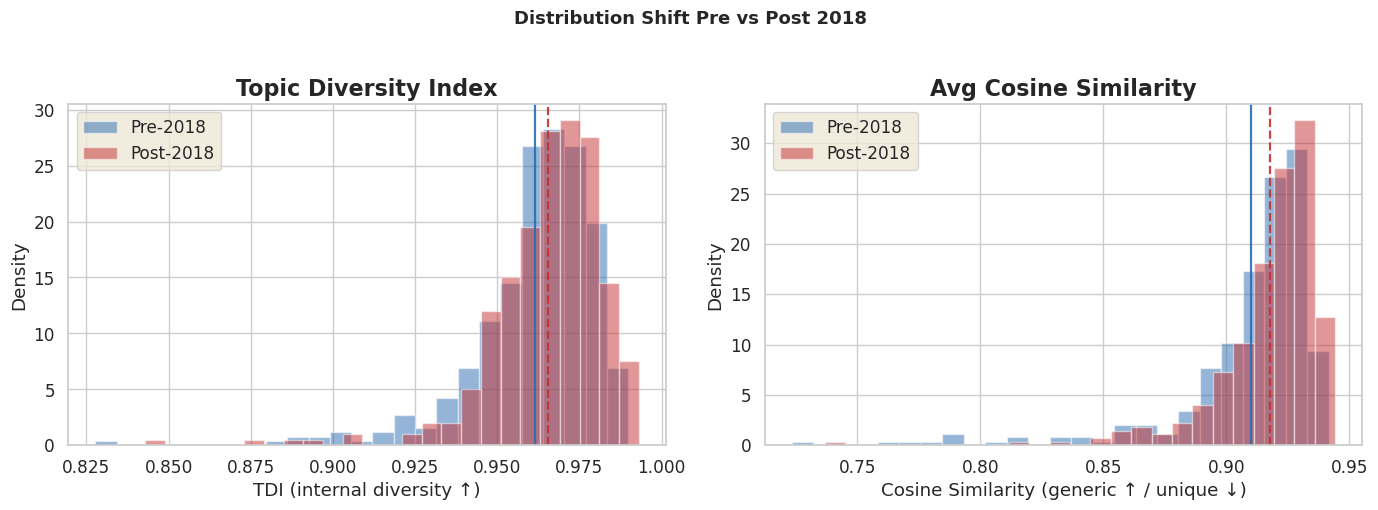

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plt.style.use('Solarize_Light2')

for ax, col, title, label in [
    (axes[0], 'TDI', 'Topic Diversity Index', 'TDI (internal diversity ↑)'),
    (axes[1], 'mean_cosine_similarity', 'Avg Cosine Similarity', 'Cosine Similarity (generic ↑ / unique ↓)'),
]:
    for era, color, ls in [
        ('Pre-2018',  BLUE,  '-'),
        ('Post-2018', RED, '--'),
    ]:
        sub = df[df['era'] == era][col].dropna()
        ax.hist(sub, bins=25, alpha=0.5, density=True,
                color=color, label=era, edgecolor='white')
        ax.axvline(sub.mean(), color=color, linestyle=ls,
                   linewidth=1.6, alpha=0.9)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Distribution Shift Pre vs Post 2018', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + '1_distribution_by_era.png')
plt.show()

## 6. Time Series with 2018 Discontinuity

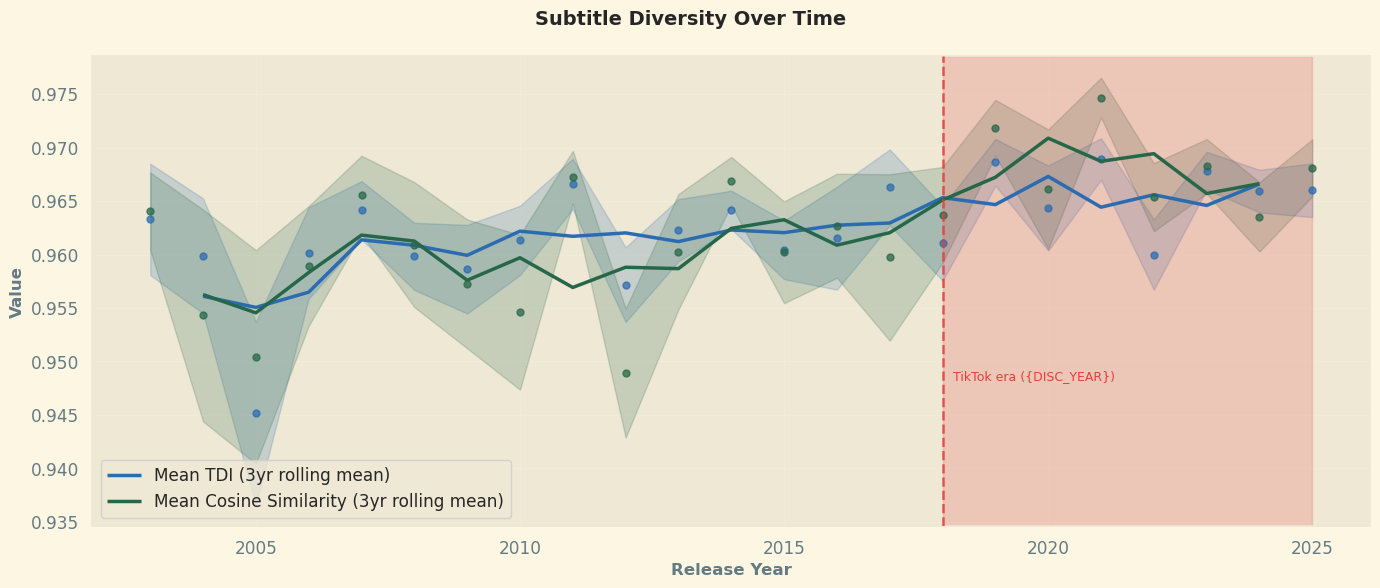

In [11]:
def mark_discontinuity(ax, year=DISC_YEAR, label='TikTok era ({DISC_YEAR})'):
    ax.axvline(year, color=DISC_COLOR, linewidth=1.8, linestyle='--', alpha=0.85, zorder=5)
    ax.text(year + 0.2, ax.get_ylim()[1] * 0.97, label,
            color=DISC_COLOR, fontsize=9, va='top')

yearly = (
    df.dropna(subset=['startYear'])
      .groupby('startYear')
      .agg(
          n_films = ('imdb_id', 'nunique'),
          mean_TDI = ('TDI', 'mean'),
          se_TDI = ('TDI', lambda x: x.sem()),
          mean_cosine_similarity = ('mean_cosine_similarity', 'mean'),
          se_cosine = ('mean_cosine_similarity', lambda x: x.sem()),
      )
      .query('n_films >= @MIN_YEAR_FILMS')
      .reset_index()
      .sort_values('startYear')
)
yearly = yearly.astype({col: 'float64' for col in yearly.columns})
yearly = yearly.dropna(subset=['startYear'])
yearly['roll_TDI']    = yearly['mean_TDI'].rolling(3, center=True).mean()
yearly['roll_cosine'] = yearly['mean_cosine_similarity'].rolling(3, center=True).mean()

# Calculate offset to align baselines visually
offset = yearly['mean_TDI'].mean() - yearly['mean_cosine_similarity'].mean()

fig, ax = plt.subplots(1, 1, figsize=(14, 6))
plt.style.use('Solarize_Light2')

for mean_col, roll_col, se_col, color, label, off in [
    ('mean_TDI',              'roll_TDI',    'se_TDI',    BLUE,  'Mean TDI',               0),
    ('mean_cosine_similarity', 'roll_cosine', 'se_cosine', GREEN, 'Mean Cosine Similarity', offset),
]:
    ax.fill_between(yearly['startYear'],
                    yearly[mean_col] + off - yearly[se_col],
                    yearly[mean_col] + off + yearly[se_col],
                    alpha=0.2, color=color)
    ax.plot(yearly['startYear'], yearly[mean_col] + off,
            'o', color=color, alpha=0.75, markersize=5)
    ax.plot(yearly['startYear'], yearly[roll_col] + off,
            linewidth=2.5, color=color, label=f'{label} (3yr rolling mean)')

ax.axvspan(DISC_YEAR, yearly['startYear'].max(), alpha=0.2, color=DISC_COLOR)
mark_discontinuity(ax)
ax.set_xlabel('Release Year', fontweight='bold')
ax.set_ylabel('Value', fontweight='bold')
ax.legend(loc='lower left')
ax.grid(alpha=0.25)

plt.suptitle('Subtitle Diversity Over Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_PATH + '2_timeseries_by_era.png')
plt.show()

## 7. Runtime vs Metrics

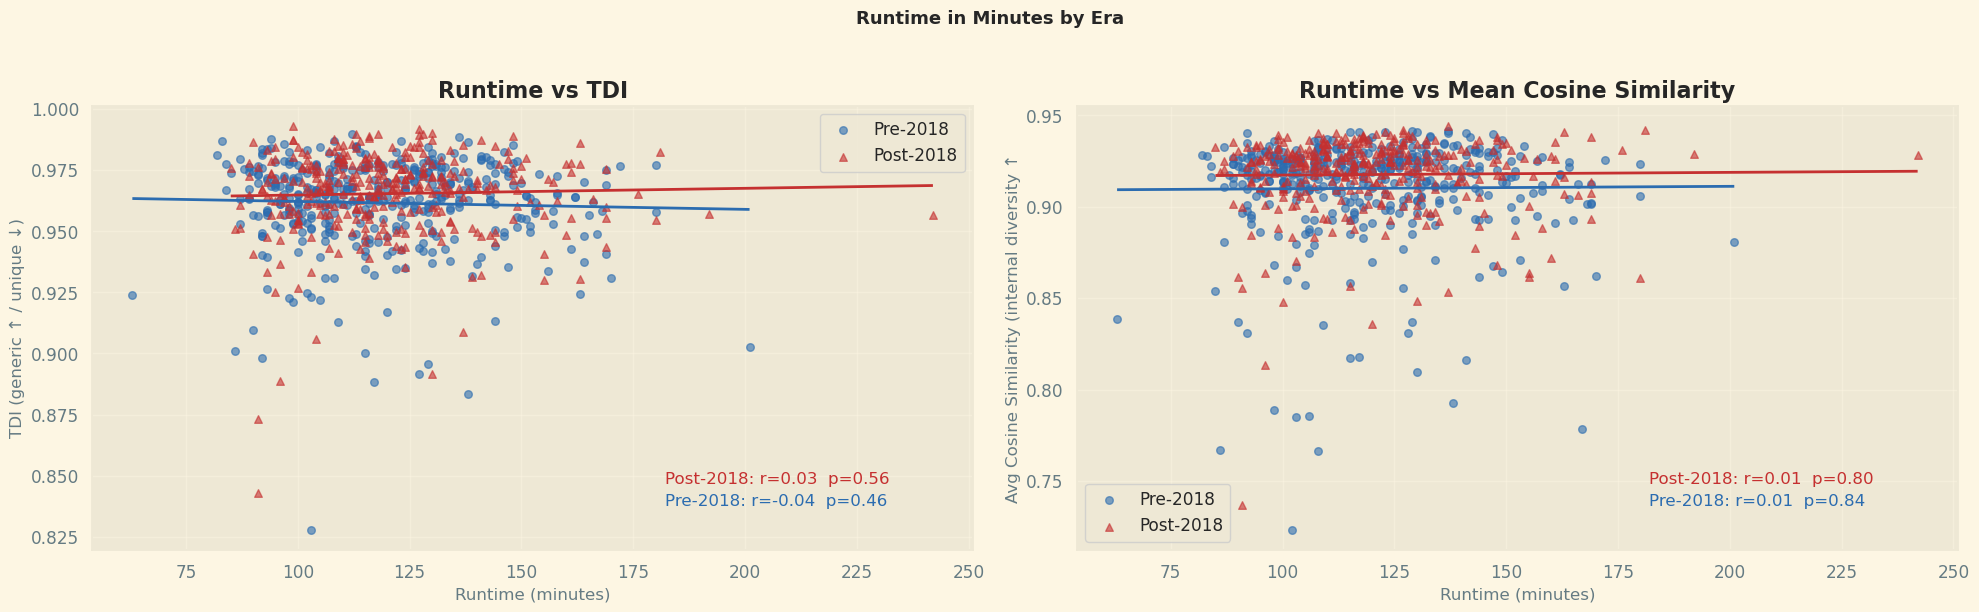

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
plt.style.use('Solarize_Light2')

plot_df = df.dropna(subset=['runtimeMinutes', 'TDI', 'mean_cosine_similarity',
                             'numVotes', 'era']).copy()

# ── 1. Runtime vs TDI ─────────────────────────────────────────────
ax = axes[0]
for (era, color, marker), y_pos in zip([('Pre-2018', BLUE, 'o'), ('Post-2018', RED, '^')],
        [0.1, 0.15]):
    sub = plot_df[plot_df['era'] == era]
    ax.scatter(sub['runtimeMinutes'], sub['TDI'],
               color=color, marker=marker, alpha=0.6, s=30, label=era)
    if len(sub) >= 2:
        m, b, r, p, _ = stats.linregress(sub['runtimeMinutes'].values, sub['TDI'].values)
        x_line = np.linspace(sub['runtimeMinutes'].min(), sub['runtimeMinutes'].max(), 100)
        ax.plot(x_line, m * x_line + b, color=color, linewidth=2)
        ax.text(0.65, y_pos, f"{era}: r={r:.2f}  p={p:.2f}", transform=ax.transAxes, fontsize=12, color=color)
ax.set_title('Runtime vs TDI', fontweight='bold')
ax.set_xlabel('Runtime (minutes)')
ax.set_ylabel('TDI (generic ↑ / unique ↓)')
ax.legend()
ax.grid(alpha=0.45)

# ── 2. Runtime vs Mean Pairwise Cosine ────────────────────────────
ax = axes[1]
for (era, color, marker), y_pos in zip([('Pre-2018', BLUE, 'o'), ('Post-2018', RED, '^')],
        [0.1, 0.15]):
    sub = plot_df[plot_df['era'] == era]
    ax.scatter(sub['runtimeMinutes'], sub['mean_cosine_similarity'],
               color=color, marker=marker, alpha=0.6, s=30, label=era)
    if len(sub) >= 2:
        m, b, r, p, _ = stats.linregress(sub['runtimeMinutes'].values,
                                     sub['mean_cosine_similarity'].values)        
        x_line = np.linspace(sub['runtimeMinutes'].min(), sub['runtimeMinutes'].max(), 100)
        ax.plot(x_line, m * x_line + b, color=color, linewidth=2)
        ax.text(0.65, y_pos, f"{era}: r={r:.2f}  p={p:.2f}", transform=ax.transAxes, fontsize=12, color=color)
ax.set_title('Runtime vs Mean Cosine Similarity', fontweight='bold')
ax.set_xlabel('Runtime (minutes)')
ax.set_ylabel('Avg Cosine Similarity (internal diversity ↑')
ax.legend()
ax.grid(alpha=0.45)

plt.suptitle('Runtime in Minutes by Era', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + '3_runtime_by_era.png')
plt.show()

## 9. Number of Ratings vs Metrics

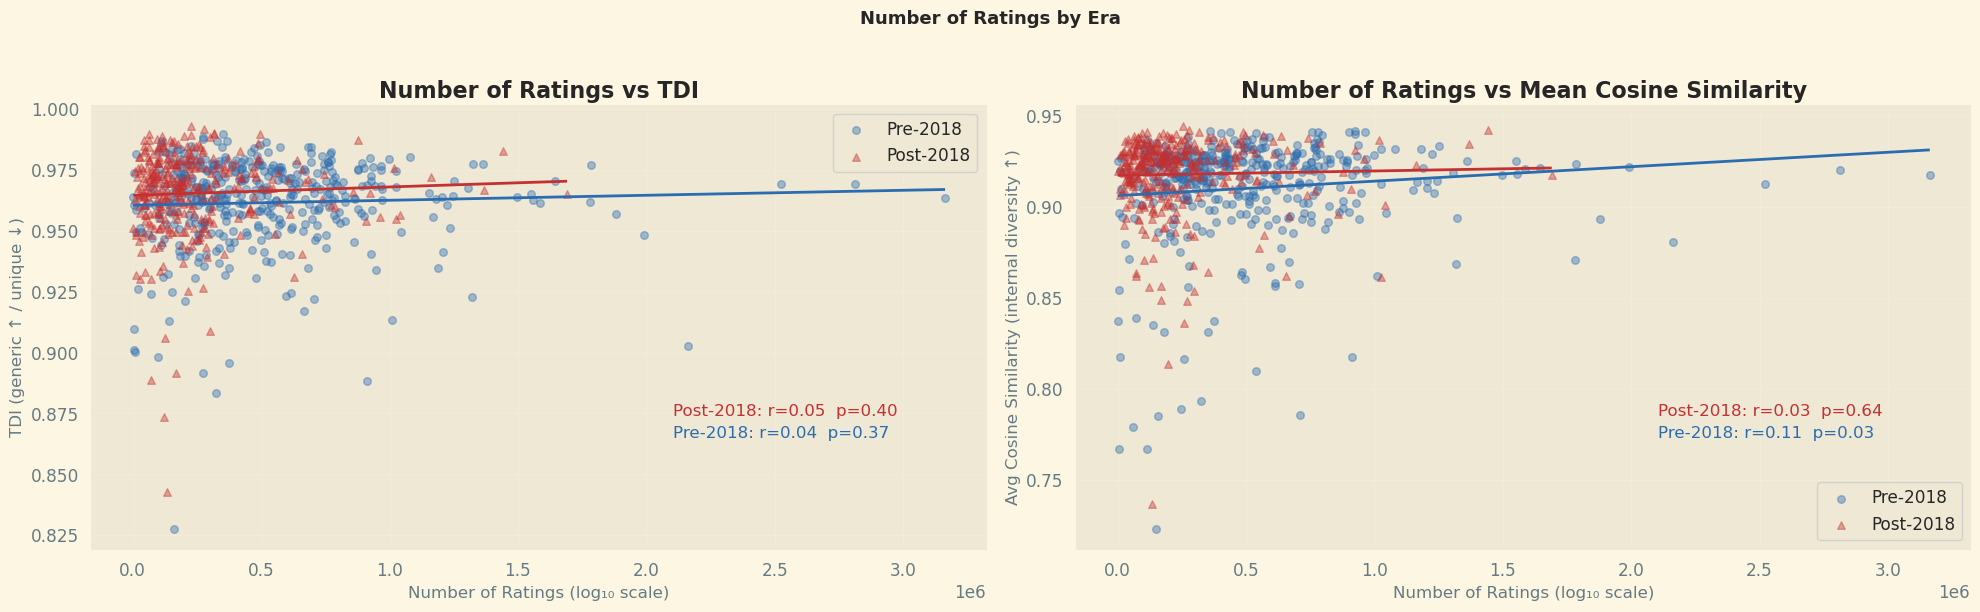

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
plt.style.use('Solarize_Light2')

plot_df = df.dropna(subset=['runtimeMinutes', 'TDI', 'mean_cosine_similarity',
                             'numVotes', 'era']).copy()

ax = axes[0]
for (era, color, marker), y_pos in zip([('Pre-2018', BLUE, 'o'), ('Post-2018', RED, '^')],
        [0.25, 0.3]):
    sub = plot_df[plot_df['era'] == era]
    ax.scatter(sub['numVotes'], sub['TDI'],
               color=color, marker=marker, alpha=0.4, s=30, label=era)
    if len(sub) >= 2:
        m, b, r, p, _ = stats.linregress(sub['numVotes'].values, sub['TDI'].values)
        x_line = np.linspace(sub['numVotes'].min(), sub['numVotes'].max(), 100)
        ax.plot(x_line, m * x_line + b, color=color, linewidth=2)
        ax.text(0.65, y_pos, f"{era}: r={r:.2f}  p={p:.2f}", transform=ax.transAxes, fontsize=12, color=color)

ax.set_title('Number of Ratings vs TDI', fontweight='bold')
ax.set_xlabel('Number of Ratings (log₁₀ scale)')
ax.set_ylabel('TDI (generic ↑ / unique ↓)')
ax.legend()
ax.grid(alpha=0.25)

ax = axes[1]
for (era, color, marker), y_pos in zip([('Pre-2018', BLUE, 'o'), ('Post-2018', RED, '^')],
        [0.25, 0.3]):
    sub = plot_df[plot_df['era'] == era]
    ax.scatter(sub['numVotes'], sub['mean_cosine_similarity'],
               color=color, marker=marker, alpha=0.4, s=30, label=era)
    if len(sub) >= 2:
        m, b, r, p, _ = stats.linregress(sub['numVotes'].values,
                                     sub['mean_cosine_similarity'].values)
        x_line = np.linspace(sub['numVotes'].min(), sub['numVotes'].max(), 100)
        ax.plot(x_line, m * x_line + b, color=color, linewidth=2)
        ax.text(0.65, y_pos, f"{era}: r={r:.2f}  p={p:.2f}", transform=ax.transAxes, fontsize=12, color=color)
ax.set_title('Number of Ratings vs Mean Cosine Similarity', fontweight='bold')
ax.set_xlabel('Number of Ratings (log₁₀ scale)')
ax.set_ylabel('Avg Cosine Similarity (internal diversity ↑)')
ax.legend()
ax.grid(alpha=0.25)
    
plt.suptitle('Number of Ratings by Era', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + '4_timeseries_metrics_by_era.png')
plt.show()

## 10. Pre vs Post 2018 — Statistical Comparison

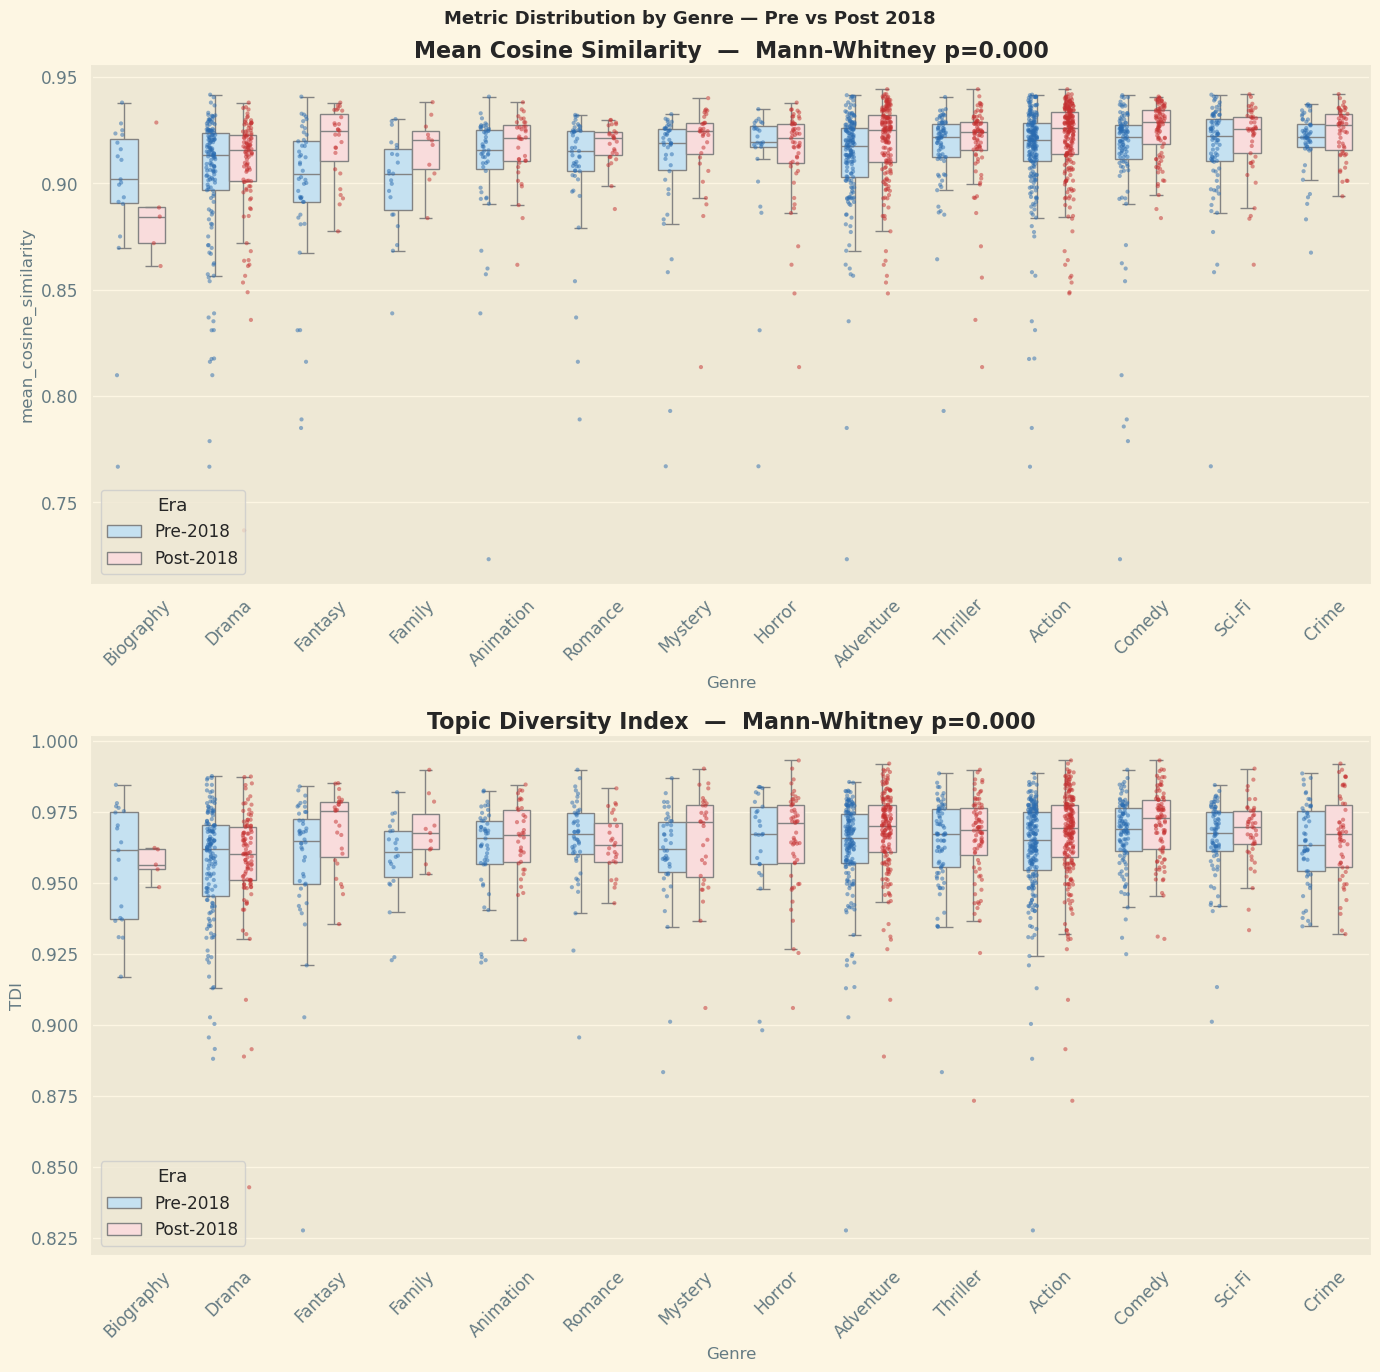

In [14]:
genre_df = (
    df
    .assign(genre=df["genres"].str.split(","))
    .explode("genre")
    .reset_index(drop=True)                         
    .assign(genre=lambda d: d["genre"].str.strip()) 
    .dropna(subset=['genre'])
)


genre_df['n_films'] = (
    genre_df.groupby(['genre', 'era'])['imdb_id']
            .transform('nunique')
)

genre_totals = (
    genre_df.groupby('genre')['n_films'].sum()
             .loc[lambda s: s >= MIN_GENRE_FILMS]
)

genre_order = (
    genre_df[genre_df['genre'].isin(genre_totals.index)]
    .groupby('genre')['mean_cosine_similarity'].mean()
    .sort_values(ascending=True)
    .index.tolist()
)

plot_data = genre_df[genre_df['genre'].isin(genre_order)]
plt.style.use('Solarize_Light2')

fig, axes = plt.subplots(2, 1, figsize=(14, 14))

for ax, col, title, label in [
    (axes[0], 'mean_cosine_similarity', 'Mean Cosine Similarity', "TDI (generic ↑ / unique ↓)"),
    (axes[1], 'TDI', 'Topic Diversity Index', "Avg Cosine Similarity (internal diversity ↑)")
]:
    sub  = plot_data[plot_data[col].notna() & plot_data['genre'].notna()].copy()

    pre  = sub[sub['era'] == 'Pre-2018'][col].dropna()
    post = sub[sub['era'] == 'Post-2018'][col].dropna()
    _, p = stats.mannwhitneyu(pre, post, alternative='two-sided')

    sns.boxplot(
        data=sub, x='genre', y=col,
        hue='era', hue_order=['Pre-2018', 'Post-2018'],
        order=genre_order,
        width=0.6, showfliers=False,
        palette={'Pre-2018': '#bee3f8', 'Post-2018': '#fed7d7'},
        ax=ax
    )
    sns.stripplot(
        data=sub, x='genre', y=col,
        hue='era', hue_order=['Pre-2018', 'Post-2018'],
        order=genre_order,
        size=3, alpha=0.5, jitter=True,
        palette={'Pre-2018': BLUE, 'Post-2018': RED},
        dodge=True, legend=False, ax=ax
    )

    ax.set_title(f'{title}  —  Mann-Whitney p={p:.3f}', fontweight='bold')
    ax.set_xlabel('Genre')
    ax.set_ylabel(col)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Era', loc='lower left')

plt.suptitle('Metric Distribution by Genre — Pre vs Post 2018',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_PATH + '5_genre_by_era.png')
plt.show()

## 11. Cosine Sim vs Release Year by Genre

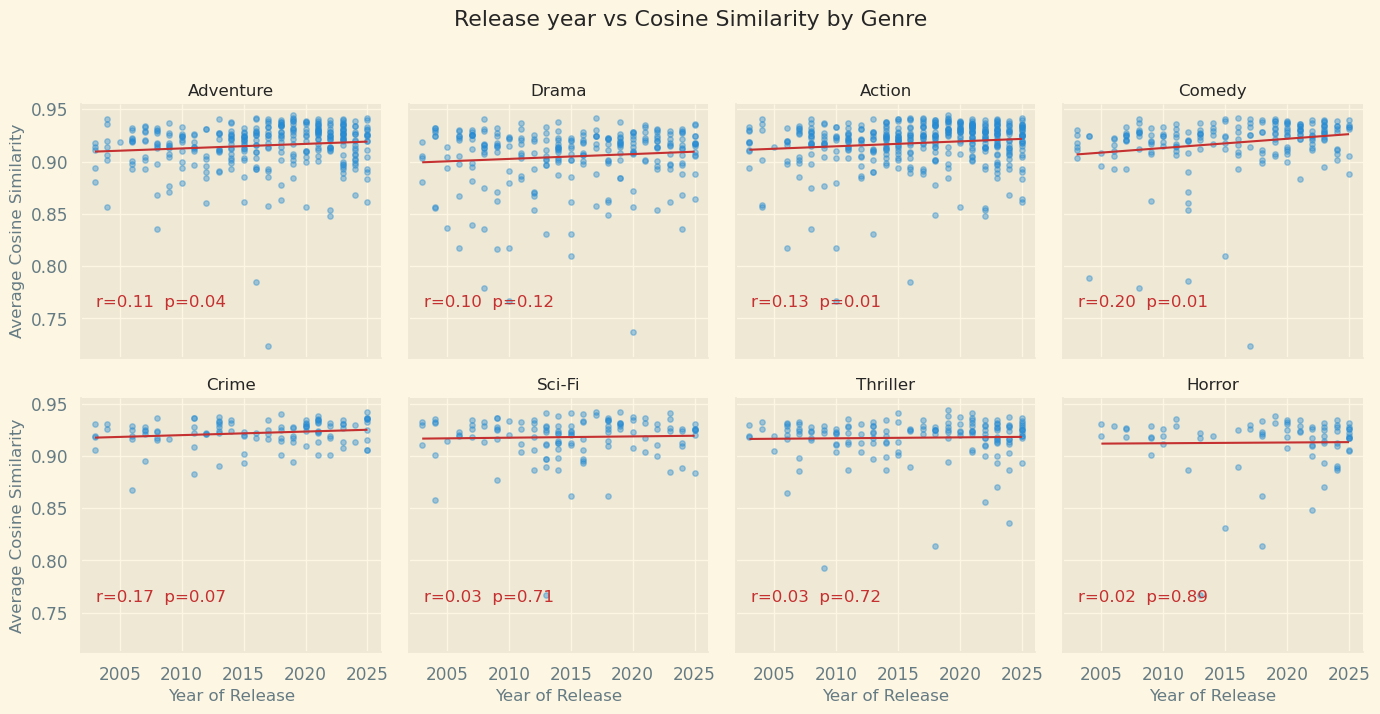

In [15]:
genre_df = (
    df
    .assign(genre=df["genres"].str.split(","))
    .explode("genre")
    .reset_index(drop=True)                         
    .assign(genre=lambda d: d["genre"].str.strip()) 
    .dropna(subset=['genre'])
)


genre_df['n_films'] = (
    genre_df.groupby(['genre', 'era'])['imdb_id']
            .transform('nunique')
)

genre_totals = (
    genre_df.groupby('genre')['n_films'].max()
             .loc[lambda s: s >= 50]
)

genre_order = (
    genre_df[genre_df['genre'].isin(genre_totals.index)]
    .groupby('genre')['mean_cosine_similarity'].mean()
    .sort_values(ascending=True)
    .index.tolist()
)

plot_data = genre_df[genre_df['genre'].isin(genre_order)]

for col in ['startYear', 'mean_cosine_similarity']:
    plot_data[col] = plot_data[col].astype(float)
    
plt.style.use('Solarize_Light2')


g = sns.FacetGrid(plot_data, col="genre", col_wrap=4, height=3.5, sharey=True, sharex=True)

def plot_with_stats(data, **kwargs):
    ax = plt.gca()
    ax.scatter(data["startYear"], data["mean_cosine_similarity"], alpha=0.4, s=15)
    if len(data) > 2:
        slope, intercept, r, p, _ = stats.linregress(
            data["startYear"], data["mean_cosine_similarity"])
        x_line = np.linspace(data["startYear"].min(), data["startYear"].max(), 100)
        ax.plot(x_line, slope * x_line + intercept, color=RED, linewidth=1.5)
        ax.text(0.05, 0.20, f"r={r:.2f}  p={p:.2f}", transform=ax.transAxes, fontsize=12, color=RED)

g.map_dataframe(plot_with_stats)
g.set_axis_labels("Year of Release", "Average Cosine Similarity")
g.set_titles(col_template="{col_name}")
g.figure.suptitle("Release year vs Cosine Similarity by Genre", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + '6_genre_by_cossim.png')
plt.show()

## 12. Metrics vs IMDb Rating

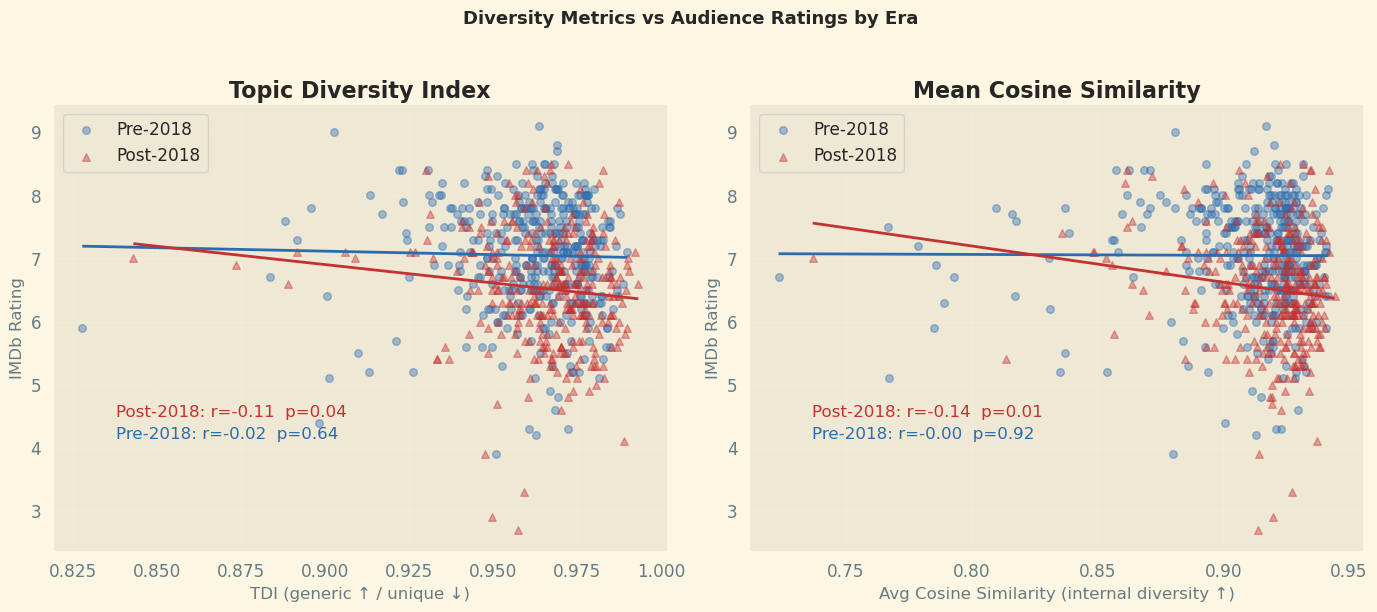

In [16]:
rated = df.dropna(subset=['averageRating', 'TDI', 'mean_cosine_similarity', 'era']).copy()

# Cast to plain float upfront so scipy and matplotlib don't hit extension types
for col in ['averageRating', 'TDI', 'mean_cosine_similarity']:
    rated[col] = rated[col].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plt.style.use('Solarize_Light2')

for ax, xcol, title, label in [
    (axes[0], 'TDI',                  'Topic Diversity Index', 'TDI (generic ↑ / unique ↓)'),
    (axes[1], 'mean_cosine_similarity',  'Mean Cosine Similarity', 'Avg Cosine Similarity (internal diversity ↑)')]:
    
    for (era, color, marker), ypos, in zip([
        ('Pre-2018',  BLUE, 'o'),
        ('Post-2018', RED,  '^'),
    ], [0.25, 0.3]):
        sub = rated[rated['era'] == era]
        if len(sub) < 2:
            continue
        ax.scatter(sub[xcol], sub['averageRating'],
                   color=color, marker=marker, alpha=0.4, s=30, label=era)
        m, b, r, p, _ = stats.linregress(sub[xcol].values, sub['averageRating'].values)
        x_line = np.linspace(sub[xcol].min(), sub[xcol].max(), 100)
        ax.plot(x_line, m * x_line + b, color=color, linewidth=2)
        ax.text(0.1, ypos, f"{era}: r={r:.2f}  p={p:.2f}", transform=ax.transAxes, fontsize=12, color=color)

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('IMDb Rating')
    ax.legend()
    ax.grid(alpha=0.25)

plt.suptitle('Diversity Metrics vs Audience Ratings by Era',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + '7_ratings_by_era.png')
plt.show()

## 13. Spearman Correlation Matrix

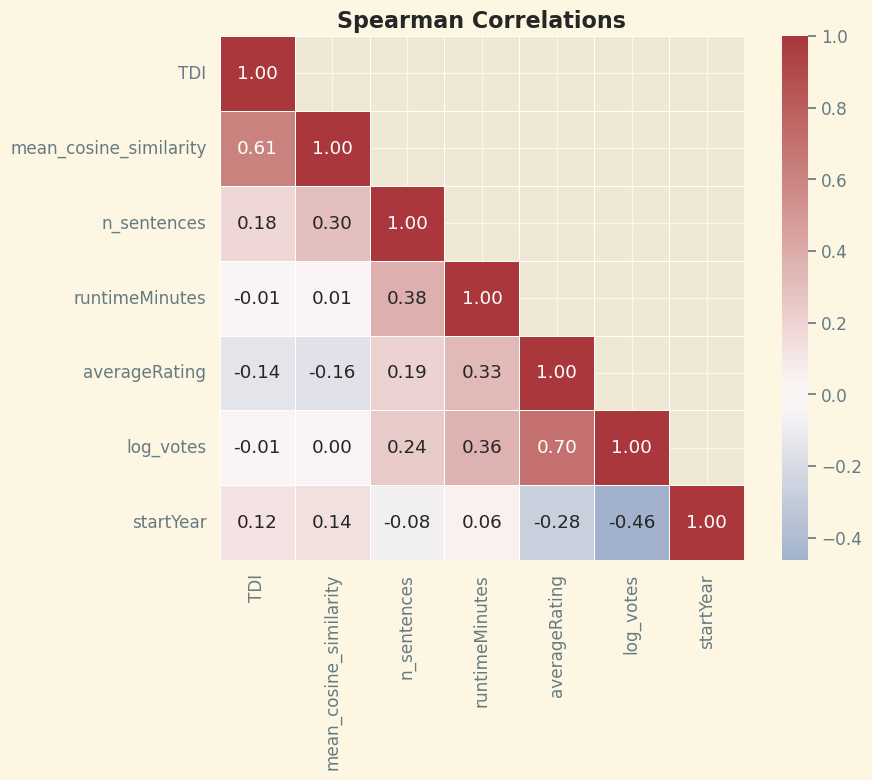

In [17]:
corr_cols = ['TDI', 'mean_cosine_similarity', 
             'n_sentences', 'runtimeMinutes', 'averageRating', 'log_votes', 'startYear']
corr = df[corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
plt.style.use('Solarize_Light2')
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='vlag', center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Spearman Correlations', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_PATH + '8_timeseries_by_era.png')
plt.show()

In [18]:
## 14. Internal diversity vs external uniqueness

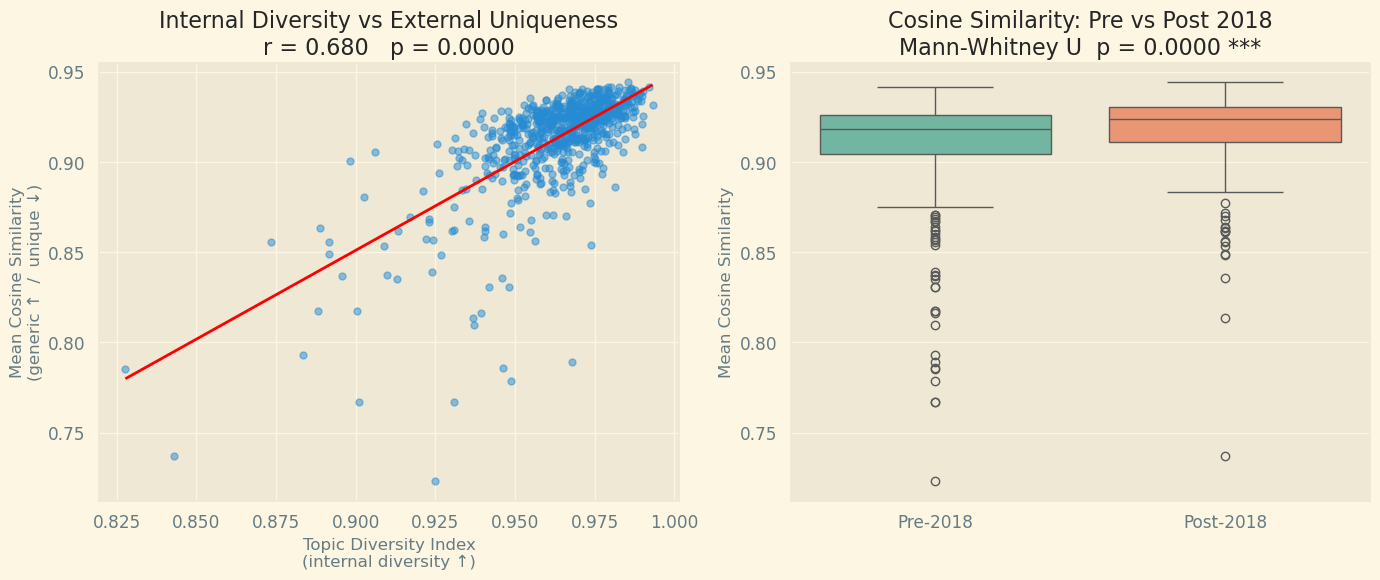

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Plot 1: Internal diversity vs external uniqueness ─────────────────────────
plot_data = df[["TDI", "mean_cosine_similarity"]].dropna()
plt.style.use('Solarize_Light2')

axes[0].scatter(plot_data["TDI"], plot_data["mean_cosine_similarity"],
                alpha=0.5, s=25)
slope, intercept, r, p, _ = stats.linregress(
    plot_data["TDI"], plot_data["mean_cosine_similarity"])
x_line = np.linspace(plot_data["TDI"].min(),
                     plot_data["TDI"].max(), 100)
axes[0].plot(x_line, slope * x_line + intercept, color="red", linewidth=2)
axes[0].ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
axes[0].set_xlabel("Topic Diversity Index\n(internal diversity ↑)")
axes[0].set_ylabel("Mean Cosine Similarity\n(generic ↑  /  unique ↓)")
axes[0].set_title(f"Internal Diversity vs External Uniqueness\nr = {r:.3f}   p = {p:.4f}")

# ── Plot 2: Pre vs Post 2018 boxplot ──────────────────────────────────────────
df_era = df.dropna(subset=["startYear", "mean_cosine_similarity"]).copy()
df_era["startYear"] = pd.to_numeric(df_era["startYear"], errors="coerce")
df_era["era"] = np.where(df_era["startYear"] < 2018, "Pre-2018", "Post-2018")
sns.boxplot(data=df_era, x="era", y="mean_cosine_similarity",
            palette="Set2", ax=axes[1], order=["Pre-2018", "Post-2018"])
pre  = df_era[df_era["era"] == "Pre-2018"]["mean_cosine_similarity"]
post = df_era[df_era["era"] == "Post-2018"]["mean_cosine_similarity"]
u, p_val = stats.mannwhitneyu(pre, post, alternative="two-sided")
sig = "***" if p_val < .001 else ("**" if p_val < .01 else ("*" if p_val < .05 else "ns"))
axes[1].set_title(f"Cosine Similarity: Pre vs Post 2018\nMann-Whitney U  p = {p_val:.4f} {sig}")
axes[1].set_ylabel("Mean Cosine Similarity")
axes[1].set_xlabel("")

plt.tight_layout()
plt.savefig(OUTPUT_PATH + '9_internalvsexternal.png')
plt.show()

# 15. 2x2 grid: Internal Diversity (TDI) vs External Uniqueness (cosine) 

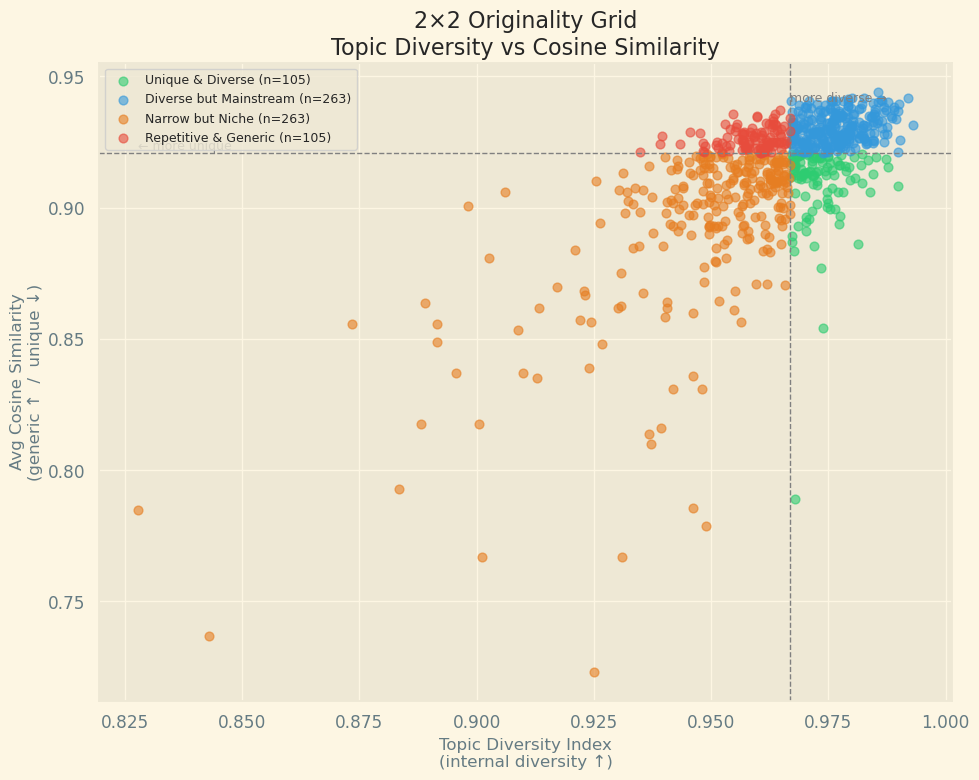

In [20]:
fig, ax = plt.subplots(figsize=(10, 8))

plot_data = df[["TDI", "mean_cosine_similarity", "title"]].dropna()

# Medians as cutoff thresholds for the quadrants
var_x = plot_data["TDI"].median()
var_y = plot_data["mean_cosine_similarity"].median()

# Colour each point by quadrant
def quadrant(row):
    if row["TDI"] >= var_x and row["mean_cosine_similarity"] <  var_y:
        return "Unique & Diverse"       # top-left  (most original)
    elif row["TDI"] >= var_x and row["mean_cosine_similarity"] >= var_y:
        return "Diverse but Mainstream" # top-right
    elif row["TDI"] <  var_x and row["mean_cosine_similarity"] <  var_y:
        return "Narrow but Niche"       # bottom-left
    else:
        return "Repetitive & Generic"   # bottom-right (least original)

plot_data["quadrant"] = plot_data.apply(quadrant, axis=1)

palette = {
    "Unique & Diverse":       "#2ecc71",
    "Diverse but Mainstream": "#3498db",
    "Narrow but Niche":       "#e67e22",
    "Repetitive & Generic":   "#e74c3c",
}

for quad, color in palette.items():
    sub = plot_data[plot_data["quadrant"] == quad]
    ax.scatter(sub["TDI"], sub["mean_cosine_similarity"],
               label=f"{quad} (n={len(sub)})", color=color, alpha=0.6, s=40)

# Quadrant dividers
ax.axvline(var_x, color="gray", linestyle="--", linewidth=1)
ax.axhline(var_y, color="gray", linestyle="--", linewidth=1)

# Quadrant labels
ax.text(plot_data["TDI"].min(), var_y + 0.0001,
        "← more unique", fontsize=9, color="gray", va="bottom")
ax.text(var_x + 0.000005, plot_data["mean_cosine_similarity"].max(),
        "more diverse →", fontsize=9, color="gray", ha="left", va="top")

ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
ax.set_xlabel("Topic Diversity Index\n(internal diversity ↑)")
ax.set_ylabel("Avg Cosine Similarity\n(generic ↑  /  unique ↓)")
ax.set_title("2×2 Originality Grid\nTopic Diversity vs Cosine Similarity")
ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + '10_2x2_metrics.png')
plt.show()


## 16. Interactive Plot

In [21]:
plot_data = df[["title", "TDI", "mean_cosine_similarity",
                    "averageRating", "numVotes", "genres", "startYear"]].dropna(
                    subset=["TDI", "mean_cosine_similarity"])

plot_data["startYear"]  = pd.to_numeric(plot_data["startYear"], errors="coerce")
plot_data["numVotes"]   = pd.to_numeric(plot_data["numVotes"],  errors="coerce")
plot_data["era"]        = np.where(plot_data["startYear"] < 2018, "Pre-2018", "Post-2018")

# Size bubbles by numVotes (popularity)
plot_data["bubble_size"] = (plot_data["numVotes"].fillna(1000) / plot_data["numVotes"].max() * 40 + 4)

fig = px.scatter(
    plot_data,
    x="TDI",
    y="mean_cosine_similarity",
    color="era",
    size="bubble_size",
    size_max=30,
    hover_name="title",
    hover_data={
        "TDI": ":.5f",
        "mean_cosine_similarity":  ":.5f",
        "averageRating":          True,
        "numVotes":               ":,.0f",
        "genres":                 True,
        "startYear":              True,
        "bubble_size":            False,
        "era":                    False,
    },
    color_discrete_map={"Pre-2018": "#4C72B0", "Post-2018": "#DD8452"},
    labels={
        "TDI": "Topic Diversity Index (internal diversity ↑)",
        "mean_cosine_similarity":  "Avg Cosine Similarity (generic ↑ / unique ↓)",
    },
    title="Internal Diversity vs External Uniqueness<br><sup>Bubble size = IMDb votes (popularity) · Hover for movie details</sup>",
)

# Add quadrant lines at medians
med_x = plot_data["TDI"].median()
med_y = plot_data["mean_cosine_similarity"].median()

fig.add_vline(x=med_x, line_dash="dash", line_color="gray", opacity=0.5)
fig.add_hline(y=med_y, line_dash="dash", line_color="gray", opacity=0.5)

# Quadrant labels
quadrants = [
    (med_x * 1.001, med_y * 1.0005, "Diverse & Generic",   "gray"),
    (med_x * 0.999, med_y * 1.0005, "Narrow & Generic",    "gray"),
    (med_x * 1.001, med_y * 0.9995, "Diverse & Unique",  "green"),
    (med_x * 0.999, med_y * 0.9995, "Narrow & Unique",     "gray"),
]
for x, y, label, color in quadrants:
    fig.add_annotation(x=x, y=y, text=label, showarrow=False,
                       font=dict(size=10, color=color), opacity=0.6)

fig.update_layout(
    width=1000, height=650,
    legend_title="Era",
    xaxis=dict(tickformat=".4e"),
    hoverlabel=dict(bgcolor="white", font_size=12),
    template="plotly_white",
)

fig.write_html("/tmp/cosine_scatter_interactive.html")
fig.show()

## 17. Box Office vs Metrics

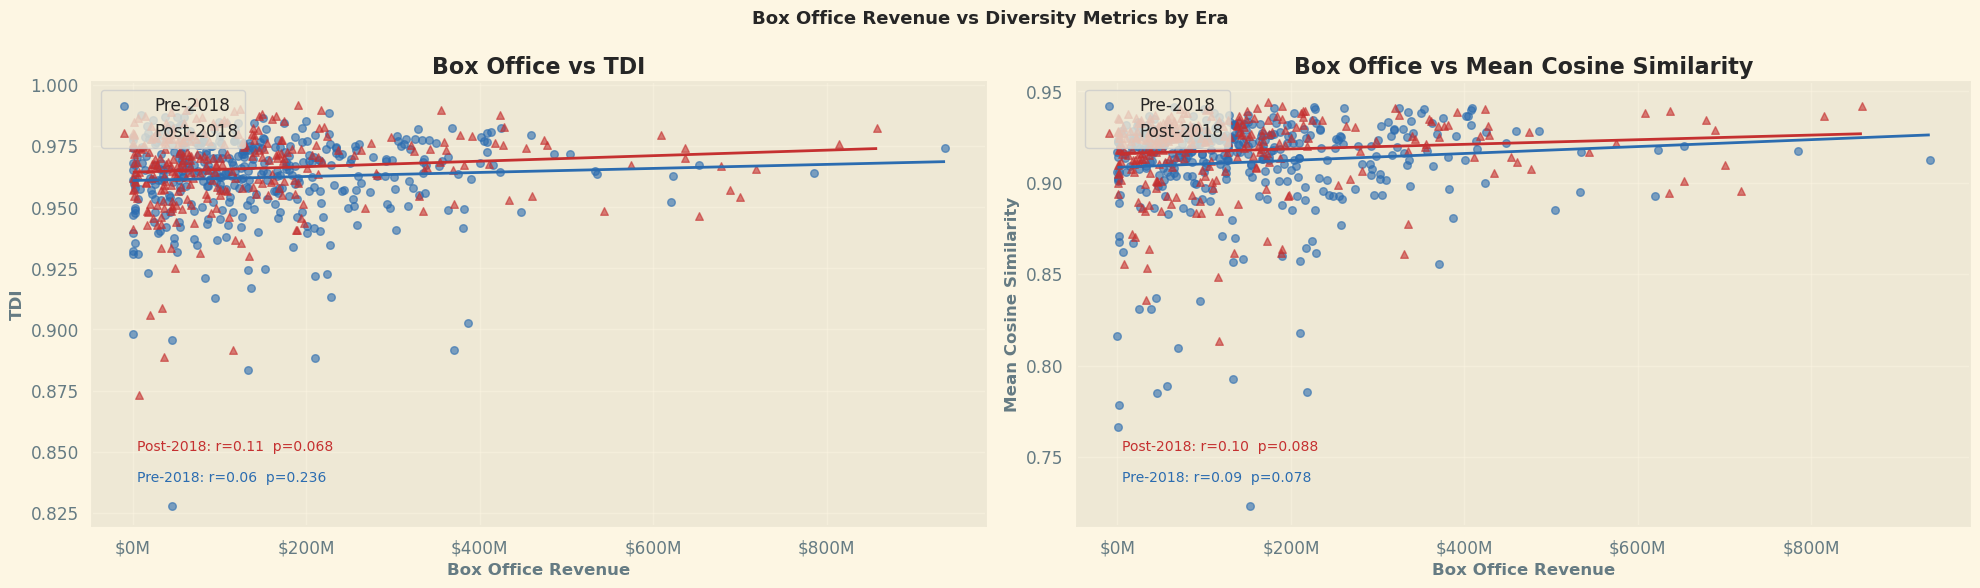

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
plt.style.use('Solarize_Light2')

plot_df = df.dropna(subset=['box_office', 'TDI', 'mean_cosine_similarity', 'era']).copy()

for (ax, y_col, y_label), y_pos in zip(
    [
        (axes[0], 'TDI',                    'TDI'),
        (axes[1], 'mean_cosine_similarity',  'Mean Cosine Similarity'),
    ],
    [0.92, 0.92]
):
    for (era, color, marker), text_y in zip(
        [('Pre-2018', BLUE, 'o'), ('Post-2018', RED, '^')],
        [0.10, 0.17]
    ):
        sub = plot_df[plot_df['era'] == era]
        ax.scatter(sub['box_office'], sub[y_col],
                   color=color, marker=marker, alpha=0.6, s=30, label=era)

        if len(sub) >= 2:
            m, b, r, p, _ = stats.linregress(sub['box_office'].values, sub[y_col].values)
            x_line = np.linspace(sub['box_office'].min(), sub['box_office'].max(), 100)
            ax.plot(x_line, m * x_line + b, color=color, linewidth=2)
            ax.text(0.05, text_y, f"{era}: r={r:.2f}  p={p:.3f}",
                    transform=ax.transAxes, fontsize=10, color=color)

    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'${x/1e6:.0f}M' if x < 1e9 else f'${x/1e9:.1f}B'
    ))
    ax.set_title(f'Box Office vs {y_label}', fontweight='bold')
    ax.set_xlabel('Box Office Revenue', fontweight='bold')
    ax.set_ylabel(y_label, fontweight='bold')
    ax.legend(loc='upper left')
    ax.grid(alpha=0.45)

plt.suptitle('Box Office Revenue vs Diversity Metrics by Era', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_PATH + '11_boxoffice_vs_metrics.png')
plt.show()

## 18. Export

In [23]:
df.to_csv(OUTPUT_PATH + 'topic_diversity_imdb_eda.csv', index=False)
print(f"Saved {len(df):,} rows to {OUTPUT_PATH + 'topic_diversity_imdb_eda.csv'}")
df[['imdb_id', 'primaryTitle', 'startYear', 'era',
    'TDI', 'mean_cosine_similarity', 'averageRating']].head(10)

Saved 736 rows to home/MoviesLSE/topic_diversity_imdb_eda.csv


,imdb_id,primaryTitle,startYear,era,TDI,mean_cosine_similarity,averageRating
0,167260,The Lord of the Rings: The Return of the King,2003,Pre-2018,0.9027,0.8807,9.0000
1,172156,Bad Boys II,2003,Pre-2018,0.9744,0.9300,6.6000
2,234215,The Matrix Reloaded,2003,Pre-2018,0.9630,0.9106,7.2000
3,242653,The Matrix Revolutions,2003,Pre-2018,0.9845,0.9326,6.7000
4,251127,How to Lose a Guy in 10 Days,2003,Pre-2018,0.9639,0.9250,6.5000
5,259324,Ghost Rider,2007,Pre-2018,0.9675,0.9323,5.3000
6,265208,The Girl Next Door,2004,Pre-2018,0.9787,0.9246,6.7000
7,266543,Finding Nemo,2003,Pre-2018,0.9414,0.9142,8.2000
8,266697,Kill Bill: Vol. 1,2003,Pre-2018,0.9675,0.9181,8.2000
9,274166,Johnny English,2003,Pre-2018,0.9796,0.9106,6.3000
